In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyreadr
from typing import Dict
from peshbeen.models import ml_forecaster
from peshbeen.model_selection import optuna_tune, hyperopt_tune, SplitTimeSeries
from peshbeen.statstools import unit_root_test
from peshbeen.metrics import RMSE, MSE
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import OneHotEncoder

In [43]:
def load_rds_to_df(file_path: str) -> pd.DataFrame:
    """
    Reads an R RDS file and returns a memory-optimized Pandas DataFrame.
    """
    try:
        # pyreadr returns a dictionary even for single RDS objects
        result: Dict = pyreadr.read_r(file_path)
        
        # The key is None for RDS files (unlike .RData files)
        df: pd.DataFrame = result[None]
        
        # Proactive Data Cleansing: Check for R-specific nulls or type issues
        # Convert objects to categories if cardinality is low to save memory
        for col in df.select_dtypes(include=['object']).columns:
            if df[col].nunique() / len(df) < 0.5:
                df[col] = df[col].astype('category')
                
        return df

    except FileNotFoundError:
        print(f"Error: The file at {file_path} was not found.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred during ingestion: {e}")
        raise

# Execution
tidy_df = load_rds_to_df("../data/nhs_ead_tidy.rds")[:-1]
# tidy_df_feat = load_rds_to_df("../data/daily_features_long.rds")

In [44]:
## the columns with number of NANs largter than 365
nan_counts = tidy_df.isna().sum()
cols_to_drop = nan_counts[nan_counts > 30].index
tidy_df.drop(columns=cols_to_drop, inplace=True)

In [45]:
## fill forward the rest of the NANs
tidy_df.fillna(method='ffill', inplace=True)

In [46]:
import sys; print(sys.executable)
import peshbeen; print(peshbeen.__version__)

/usr/local/bin/python3
0.0.22


In [50]:
tidy_df["forecast_date"] = pd.to_datetime(tidy_df["forecast_date"])
tidy_dfx = tidy_df.set_index('forecast_date')

In [52]:
target_var = "estimated_avoidable_deaths"
num_cols = tidy_dfx.columns.drop(target_var).tolist()

In [53]:
tidy_dfx["day_of_week"] = tidy_dfx.index.dayofweek
tidy_dfx["month"] = tidy_dfx.index.month
cat_vars = ["day_of_week", "month"]

In [54]:
## generate lag 1 to 10 for all num calls
for col in num_cols:
    for lag in range(1, 11):
        tidy_dfx[f"{col}_lag_{lag}"] = tidy_dfx[col].shift(lag)
## drop original num cols
tidy_dfx.drop(columns=num_cols, inplace=True)
tidy_dfx.dropna(inplace=True)

In [61]:
train_dfx = tidy_dfx[:-180]
test_dfx = tidy_dfx[-180:]
train_dfx

,estimated_avoidable_deaths,day_of_week,month,(SWASFT) Number of HCP Incidents_lag_1,(SWASFT) Number of HCP Incidents_lag_2,(SWASFT) Number of HCP Incidents_lag_3,(SWASFT) Number of HCP Incidents_lag_4,(SWASFT) Number of HCP Incidents_lag_5,(SWASFT) Number of HCP Incidents_lag_6,(SWASFT) Number of HCP Incidents_lag_7,...,Resuscitation Capacity at 1000_lag_1,Resuscitation Capacity at 1000_lag_2,Resuscitation Capacity at 1000_lag_3,Resuscitation Capacity at 1000_lag_4,Resuscitation Capacity at 1000_lag_5,Resuscitation Capacity at 1000_lag_6,Resuscitation Capacity at 1000_lag_7,Resuscitation Capacity at 1000_lag_8,Resuscitation Capacity at 1000_lag_9,Resuscitation Capacity at 1000_lag_10
forecast_date,,,,,,,,,,,,,,,,,,,,,
2023-03-26,0.561647,6,3,22.0,40.0,51.0,51.0,58.0,29.0,23.0,...,5.0,3.0,3.0,3.0,1.0,0.0,3.0,3.0,7.0,5.0
2023-03-27,0.677832,0,3,23.0,22.0,40.0,51.0,51.0,58.0,29.0,...,4.0,5.0,3.0,3.0,3.0,1.0,0.0,3.0,3.0,7.0
2023-03-28,1.207062,1,3,60.0,23.0,22.0,40.0,51.0,51.0,58.0,...,2.0,4.0,5.0,3.0,3.0,3.0,1.0,0.0,3.0,3.0
2023-03-29,0.838946,2,3,59.0,60.0,23.0,22.0,40.0,51.0,51.0,...,4.0,2.0,4.0,5.0,3.0,3.0,3.0,1.0,0.0,3.0
2023-03-30,0.832692,3,3,59.0,59.0,60.0,23.0,22.0,40.0,51.0,...,3.0,4.0,2.0,4.0,5.0,3.0,3.0,3.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-29,0.677095,5,3,85.0,73.0,55.0,37.0,62.0,31.0,34.0,...,1.0,3.0,2.0,2.0,4.0,2.0,4.0,4.0,1.0,3.0
2025-03-30,0.513272,6,3,53.0,85.0,73.0,55.0,37.0,62.0,31.0,...,3.0,1.0,3.0,2.0,2.0,4.0,2.0,4.0,4.0,1.0
2025-03-31,0.820709,0,3,31.0,53.0,85.0,73.0,55.0,37.0,62.0,...,2.0,3.0,1.0,3.0,2.0,2.0,4.0,2.0,4.0,4.0


In [120]:
target_lags = list(range(3, 22))
my_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
xgb_model = ml_forecaster(model = XGBRegressor(random_state=42), target_col= target_var,
              lags=target_lags, cat_variables=cat_vars,
            categorical_encoder = my_encoder)
lasso_model = ml_forecaster(model = Lasso(random_state=42), target_col= target_var,
              lags=target_lags, cat_variables=cat_vars,
            categorical_encoder = my_encoder)

In [ ]:
lasso_model.cross_validate(train_dfx,
                         cv_split=10,
                         step_size=1, test_size=5, metrics=[MSE])

,cutoff,index,split,y_true,y_pred
0,2025-03-20,2025-03-20,fold_1,0.586389,0.568958
1,2025-03-20,2025-03-21,fold_1,0.789182,0.674810
2,2025-03-20,2025-03-22,fold_1,0.510296,0.598331
3,2025-03-20,2025-03-23,fold_1,0.929969,0.631032
4,2025-03-20,2025-03-24,fold_1,0.817051,0.719463
5,2025-03-21,2025-03-21,fold_2,0.789182,0.598410
6,2025-03-21,2025-03-22,fold_2,0.510296,0.583639
7,2025-03-21,2025-03-23,fold_2,0.929969,0.763738
8,2025-03-21,2025-03-24,fold_2,0.817051,0.859822
9,2025-03-21,2025-03-25,fold_2,0.961574,0.907409


In [87]:
# get feature importance and sort by importance
# names = xgb_model.model.feature_names_in_
# importances = xgb_model.model.feature_importances_
# feature_importance_df = pd.DataFrame({'feature': xgb_model.model.feature_names_in_, 'importance': xgb_model.model.feature_importances_})
# feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

In [88]:
# xgb_model.forecast(H=180, exog=test_dfx.drop(columns=target_var))

In [121]:
# xgb_param_space = {
#     # 1. Step Size & Complexity
#     "learning_rate": lambda t: t.suggest_float("learning_rate", 1e-3, 0.7, log=True),
#     "max_depth": lambda t: t.suggest_int("max_depth", 3, 16),
#     "n_estimators": lambda t: t.suggest_int("n_estimators", 50, 1500),
    
#     # 2. Stochastic Sampling (Adding Noise to prevent overfitting)
#     "subsample": lambda t: t.suggest_float("subsample", 0.5, 1.0),
#     "colsample_bytree": lambda t: t.suggest_float("colsample_bytree", 0.5, 1.0),
    
#     # 3. Regularization (Crucial for Time Series)
#     "min_child_weight": lambda t: t.suggest_int("min_child_weight", 1, 10),
#     "gamma": lambda t: t.suggest_float("gamma", 1e-8, 1.0, log=True),
#     "alpha": lambda t: t.suggest_float("alpha", 1e-8, 1.0, log=True),   # L1
#     "lambda": lambda t: t.suggest_float("lambda", 1e-8, 1.0, log=True), # L2
    
#     # 4. Global Fixed Parameters (Performance & Method)
#     "tree_method": lambda t: "hist", # Use 'gpu_hist' if CUDA is available
#     "n_jobs": lambda t: -1,
#     "random_state": lambda t: 42
# }

lasso_param_space = {
    "alpha": lambda t: t.suggest_float("alpha", 1e-8, 1.0, log=True),
    "random_state": lambda t: 42
}

# best_params, best_lags, other_ags = optuna_tune(
#     model=xgb_model,
#     df=train_dfx,
#     cv_split=15,
#     step_size=12,
#     test_size=1,
#     eval_metric=MSE,
#     eval_num=100,
#     param_space=xgb_param_space, verbose=True
# )

lasso_alpha, best_lags, other_ags = optuna_tune(
    model=lasso_model,
    df=train_dfx,
    cv_split=15,
    step_size=12,
    test_size=1,
    eval_metric=MSE,
    eval_num=100,
    param_space=lasso_param_space, verbose=True
)

[I 2026-05-06 15:38:03,170] A new study created in memory with name: no-name-243c37ce-7bdf-4f7a-8a20-0b6bd4e2d518
[I 2026-05-06 15:38:04,926] Trial 0 finished with value: 0.1014452301431003 and parameters: {'alpha': 0.003887083313991737}. Best is trial 0 with value: 0.1014452301431003.


Trial    0 | score=0.101445 | {'alpha': 0.003887083313991737, 'random_state': 42}


[I 2026-05-06 15:38:06,482] Trial 1 finished with value: 0.10399697664817506 and parameters: {'alpha': 0.01271292378904076}. Best is trial 0 with value: 0.1014452301431003.


Trial    1 | score=0.103997 | {'alpha': 0.01271292378904076, 'random_state': 42} | best trial=0 | best_score=0.1014


[I 2026-05-06 15:38:08,348] Trial 2 finished with value: 0.22271053531386556 and parameters: {'alpha': 4.6918527202583874e-08}. Best is trial 0 with value: 0.1014452301431003.


...

Trial   97 | score=0.211897 | {'alpha': 1.1429016846728392e-05, 'random_state': 42} | best trial=62 | best_score=0.0996


[I 2026-05-06 15:40:50,246] Trial 98 finished with value: 0.1022359360775546 and parameters: {'alpha': 0.04384106370506005}. Best is trial 62 with value: 0.09962598092733324.


Trial   98 | score=0.102236 | {'alpha': 0.04384106370506005, 'random_state': 42} | best trial=62 | best_score=0.0996


[I 2026-05-06 15:40:52,075] Trial 99 finished with value: 0.12044980555748408 and parameters: {'alpha': 0.0014872812086433726}. Best is trial 62 with value: 0.09962598092733324.


Trial   99 | score=0.120450 | {'alpha': 0.0014872812086433726, 'random_state': 42} | best trial=62 | best_score=0.0996


In [ ]:
import pickle
# with open('parameter_configs/xgb_best_params.pkl', 'wb') as f:
#     pickle.dump(best_params, f)

# import once we have the best params
with open('parameter_configs/xgb_best_params.pkl', 'rb') as f:
    xgb_best_params = pickle.load(f)

# with open('parameter_configs/lasso_best_params.pkl', 'wb') as f:
#     pickle.dump(lasso_alpha, f)

# import once we have the best params
with open('parameter_configs/lasso_best_params.pkl', 'rb') as f:
    lasso_alpha = pickle.load(f)

In [123]:
lasso_alpha

{'alpha': 0.003408266405778599}

In [129]:
cv_features = pd.DataFrame()
xgb_model = ml_forecaster(model = XGBRegressor(**xgb_best_params, random_state=42), target_col= target_var,
              lags=target_lags, cat_variables=cat_vars,
            categorical_encoder = my_encoder)

lasso_model = ml_forecaster(model = Lasso(**lasso_alpha, random_state=42), target_col= target_var,
              lags=target_lags, cat_variables=cat_vars,
            categorical_encoder = my_encoder)

tscv = SplitTimeSeries(n_splits=15, test_size=1, step_size=12)

for idx, (train_index, test_index) in enumerate(tscv.split(train_dfx)):
    train, test = train_dfx.iloc[train_index], train_dfx.iloc[test_index]
    x_test = test.drop(columns=[target_var])
    y_test = np.array(test[target_var])
    lasso_model.fit(train)

    ## gett coeffs and their names from lasso
    coefs = lasso_model.model.coef_
    feature_names = lasso_model.model.feature_names_in_
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': coefs})
    feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
    feature_importance_df["split"] = idx
    cv_features = pd.concat([cv_features, feature_importance_df], axis=0)


In [130]:
important_feats_lasso = cv_features.groupby("feature")["importance"].mean().sort_values(ascending=False).to_frame().reset_index()

In [132]:
# important_feats_lasso
important_feats_lasso.to_excel("../data/lasso_feature_importance.xlsx", index=False)

In [134]:
important_feats_lasso["importance"] = abs(important_feats_lasso["importance"])

In [137]:
important_feats_lasso = important_feats_lasso.sort_values("importance", ascending=False)

In [138]:
important_feats_lasso

,feature,importance
0,month_2,0.025787
1,Number of Cardiac Outliers_lag_2,0.015868
2,Patients Admitted to DtA P2 - YESTERDAY'S DATA...,0.014519
645,Number of Cardiac Outliers_lag_10,0.014178
644,DtA Community P2 Bed Occupied_lag_9,0.014037
...,...,...
366,estimated_avoidable_deaths_lag_6,0.000000
367,day_of_week_3,0.000000
368,Patients Admitted to DtA P3 - YESTERDAY'S DATA...,0.000000
369,estimated_avoidable_deaths_lag_5,0.000000


In [ ]:
    # get feature importance and sort by importance
    # names = xgb_model.model.feature_names_in_
    # importances = xgb_model.model.feature_importances_
    # feature_importance_df = pd.DataFrame({'feature': xgb_model.model.feature_names_in_, 'importance': xgb_model.model.feature_importances_})
    # feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
    # feature_importance_df["split"] = idx
    # cv_features = pd.concat([cv_features, feature_importance_df], axis=0)

In [109]:
important_feats = cv_features.groupby("feature")["importance"].mean().sort_values(ascending=False).to_frame().reset_index()
#export feats as excel
important_feats.to_excel("../data/feature_importance.xlsx", index=False)

In [114]:
important_ones = important_feats[important_feats["importance"] > 0.01]

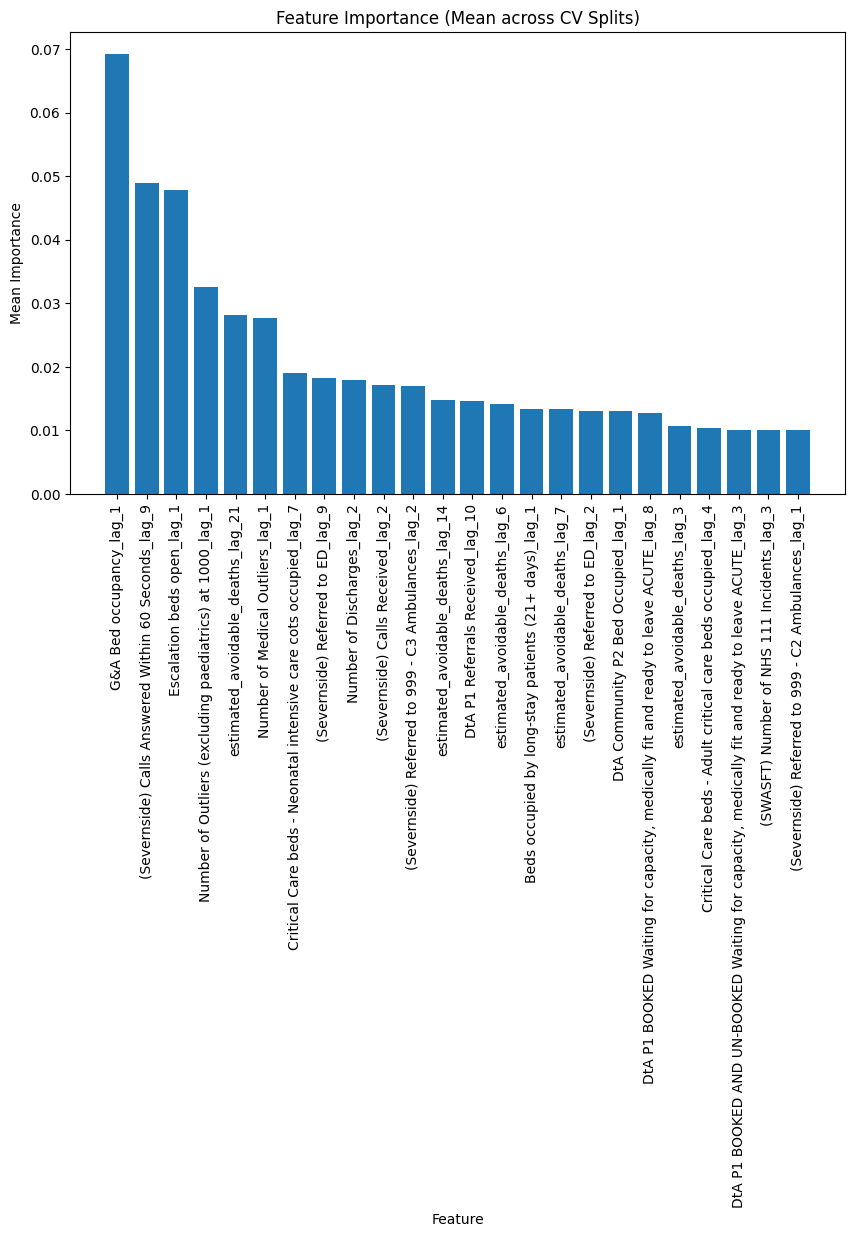

In [115]:
## plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(important_ones["feature"], important_ones["importance"])
plt.xticks(rotation=90)
plt.title("Feature Importance (Mean across CV Splits)")
plt.xlabel("Feature")
plt.ylabel("Mean Importance")
plt.tight_layout()
plt.show()

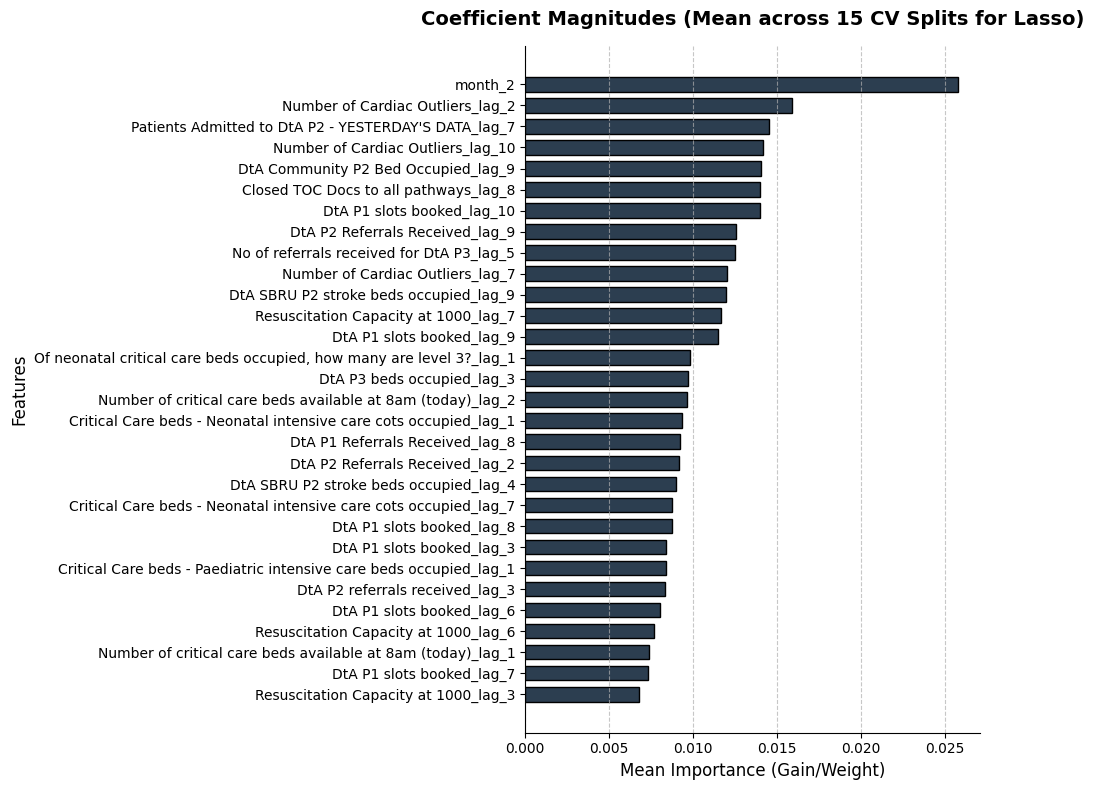

In [140]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plot_data = (
    important_feats_lasso.sort_values(by="importance", ascending=True)
    .tail(30)
)

# 2. Plotting (Horizontal for readability)
plt.figure(figsize=(10, 8), dpi=100)

# Using barh instead of bar + rotation
bars = plt.barh(
    plot_data["feature"], 
    plot_data["importance"], 
    color="#2c3e50", # Professional slate blue
    edgecolor="black",
    height=0.7
)

# 3. Aesthetics & Cleanup
plt.title("Coefficient Magnitudes (Mean across 15 CV Splits for Lasso)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mean Importance (Gain/Weight)", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Add a grid on the x-axis only to help guide the eye
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Optional: Clean up spines for a modern look
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# Execution:
# plot_feature_importance(important_ones)